# Audio MFCC + CNN (Colab)
Train an audio classifier (background/car/motorcycle/other) and export INT8 TFLite.

## 1) Install and Import Dependencies

In [ ]:
%pip install tensorflow librosa soundfile scikit-learn matplotlib kagglehub pandas seaborn

print("pip installs complete")

Defaulting to user installation because normal site-packages is not writeable
  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl.metadata (16 kB)
Using cached librosa-0.11.0-py3-none-any.whl (260 kB)
Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl (1.0 MB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------- ----------------- 4.5/8.0 MB 32.7 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 33.2 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 25.8 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ----------------- ---------------------- 16.3/38.1 MB 77.3 MB/s eta 0:00:01
   --------------------------------- ------ 32.2/38.1 MB 77.7 MB/s eta 0:00:01
   ---------------------------------------- 38.1/38.1 MB 72.3 MB/s  0:


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


2.21.0


In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

print(tf.__version__)

## 2) Dataset Paths and Classes
Organize data as data_root/class_name/*.wav

In [2]:
# If using Colab + Drive, mount here:
# from google.colab import drive
# drive.mount('/content/drive')

DATA_ROOT = "/content/drive/MyDrive/audio_dataset"  # change to your path
CLASSES = ["background", "car", "motorcycle", "other"]

SAMPLE_RATE = 16000
FRAME_SECONDS = 1.0
SAMPLES_PER_CLIP = int(SAMPLE_RATE * FRAME_SECONDS)

N_MFCC = 40
N_FFT = 512
HOP_LENGTH = 160

print("DATA_ROOT:", DATA_ROOT)
print("classes:", CLASSES)

DATA_ROOT: /content/drive/MyDrive/audio_dataset
classes: ['background', 'car', 'motorcycle', 'other']


## 2b) Download UrbanSound8K with kagglehub
Load metadata and build a file list.

In [ ]:
# Download latest version
urban_root = kagglehub.dataset_download("chrisfilo/urbansound8k")
print("UrbanSound8K root:", urban_root)


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\D\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/3 [pyyaml]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   -------------------------- ------------- 2/3 [kagglehub]
   -------------------------- ------------- 2/3 [kagglehub]
   ---------------------------------------- 3/3 [kagglehub]

Note: you may need to restart the kernel to use updated packages.


100%|██████████| 5.61G/5.61G [02:42<00:00, 37.0MB/s]

Extracting files...


UrbanSound8K root: C:\Users\D\.cache\kagglehub\datasets\chrisfilo\urbansound8k\versions\1


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\D\\.cache\\kagglehub\\datasets\\chrisfilo\\urbansound8k\\versions\\1\\UrbanSound8K\\metadata\\UrbanSound8K.csv'

In [5]:
# 1. Шлях до метаданих (файл лежить прямо в корені)
meta_path = os.path.join(urban_root, "UrbanSound8K.csv")
meta = pd.read_csv(meta_path)
print(meta.head())

# 2. Побудова шляхів до аудіофайлів (прибрали зайві "UrbanSound8K" та "audio")
meta["file_path"] = meta.apply(
    lambda r: os.path.join(urban_root, f"fold{r['fold']}", r["slice_file_name"]),
    axis=1,
)

print("total files:", len(meta))
print("classes:", sorted(meta["class"].unique()))

      slice_file_name    fsID  start        end  salience  fold  classID  \
0    100032-3-0-0.wav  100032    0.0   0.317551         1     5        3   
1  100263-2-0-117.wav  100263   58.5  62.500000         1     5        2   
2  100263-2-0-121.wav  100263   60.5  64.500000         1     5        2   
3  100263-2-0-126.wav  100263   63.0  67.000000         1     5        2   
4  100263-2-0-137.wav  100263   68.5  72.500000         1     5        2   

              class  
0          dog_bark  
1  children_playing  
2  children_playing  
3  children_playing  
4  children_playing  
total files: 8732
classes: ['air_conditioner', 'car_horn', 'children_playing', 'dog_bark', 'drilling', 'engine_idling', 'gun_shot', 'jackhammer', 'siren', 'street_music']


## 2c) Download FSC22 with kagglehub
Load metadata (if available) and build a file list.

In [ ]:
# Download latest version
fsc_root = kagglehub.dataset_download("irmiot22/fsc22-dataset")
print("FSC22 root:", fsc_root)

# Try to locate metadata CSV
csv_candidates = glob.glob(os.path.join(fsc_root, "**", "*.csv"), recursive=True)
meta_path = next(
    (p for p in csv_candidates if "meta" in os.path.basename(p).lower()),
    None,
)

if meta_path:
    meta = pd.read_csv(meta_path)
    print("metadata:", meta_path)
    print(meta.head())
else:
    print("No metadata CSV found; using folder scan.")

# Build file list from Audios folder if exists
audio_dirs = [
    p for p in glob.glob(os.path.join(fsc_root, "**", "Audios"), recursive=True)
    if os.path.isdir(p)
]

if audio_dirs:
    audio_dir = audio_dirs[0]
    wavs = glob.glob(os.path.join(audio_dir, "*.wav"))
else:
    wavs = glob.glob(os.path.join(fsc_root, "**", "*.wav"), recursive=True)

print("wav files:", len(wavs))


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


100%|██████████| 1.25G/1.25G [00:41<00:00, 32.6MB/s]

Extracting files...


FSC22 root: C:\Users\D\.cache\kagglehub\datasets\irmiot22\fsc22-dataset\versions\1
metadata: C:\Users\D\.cache\kagglehub\datasets\irmiot22\fsc22-dataset\versions\1\Metadata-20220916T202011Z-001\Metadata\Metadata V1.0 FSC22.csv
  Source File Name Dataset File Name  Class ID Class Name
0     17548__A.wav       1_10101.wav         1       Fire
1      17548_B.wav       1_10102.wav         1       Fire
2      17548_C.wav       1_10103.wav         1       Fire
3      17548_D.wav       1_10104.wav         1       Fire
4      17548_E.wav       1_10105.wav         1       Fire
wav files: 2025


## 2d) Download Vehicle Sounds with kagglehub

In [18]:
# Download latest version
vehicle_root = kagglehub.dataset_download("janboubiabderrahim/vehicle-sounds-dataset")

print("Vehicle Sounds root:", vehicle_root)

Vehicle Sounds root: C:\Users\D\.cache\kagglehub\datasets\janboubiabderrahim\vehicle-sounds-dataset\versions\1


## 2d.2) Download IDMT-Traffic with kagglehub

In [19]:
# Download latest version
idmt_root = kagglehub.dataset_download("omkarmb/idmt-traffic-dataset")

print("IDMT-Traffic root:", idmt_root)

IDMT-Traffic root: C:\Users\D\.cache\kagglehub\datasets\omkarmb\idmt-traffic-dataset\versions\1


## 2d.3) Download Brinkor Vehicle Type with kagglehub

In [20]:
# Download latest version
brinkor_root = kagglehub.dataset_download("brinkor/vehicle-type-sound-dataset")

print("Brinkor Vehicle root:", brinkor_root)

Brinkor Vehicle root: C:\Users\D\.cache\kagglehub\datasets\brinkor\vehicle-type-sound-dataset\versions\1


## 2d.1) Compact dataset diagnostics (no re-download)

In [21]:
def _root_ok(name, root):
    ok = bool(root) and os.path.isdir(root)
    print(f"{name}: {root} -> {'OK' if ok else 'MISSING'}")
    return ok


def _list_csvs(root, max_items=3):
    if not root or not os.path.isdir(root):
        return []
    csvs = glob.glob(os.path.join(root, "**", "*.csv"), recursive=True)
    return csvs[:max_items]


def _count_wavs(root, max_items=3):
    if not root or not os.path.isdir(root):
        return 0, []
    wavs = glob.glob(os.path.join(root, "**", "*.wav"), recursive=True)
    return len(wavs), wavs[:max_items]


roots = {
    "urbansound8k": globals().get("urban_root"),
    "fsc22": globals().get("fsc_root") or globals().get("fsc22_root"),
    "vehicle_sounds": globals().get("vehicle_root"),
    "idmt_traffic": globals().get("idmt_root"),
    "brinkor_vehicle": globals().get("brinkor_root"),
}

print("=== Roots ===")
for name, root in roots.items():
    _root_ok(name, root)

print("\n=== Quick scan (no downloads) ===")
for name, root in roots.items():
    if not root or not os.path.isdir(root):
        continue
    wav_count, wav_samples = _count_wavs(root)
    csv_samples = _list_csvs(root)
    print(f"\n[{name}]")
    print("wav count:", wav_count)
    print("csv samples:", csv_samples)
    print("wav samples:", wav_samples)

=== Roots ===
urbansound8k: C:\Users\D\.cache\kagglehub\datasets\chrisfilo\urbansound8k\versions\1 -> OK
fsc22: C:\Users\D\.cache\kagglehub\datasets\irmiot22\fsc22-dataset\versions\1 -> OK
vehicle_sounds: C:\Users\D\.cache\kagglehub\datasets\janboubiabderrahim\vehicle-sounds-dataset\versions\1 -> OK
idmt_traffic: C:\Users\D\.cache\kagglehub\datasets\omkarmb\idmt-traffic-dataset\versions\1 -> OK
brinkor_vehicle: C:\Users\D\.cache\kagglehub\datasets\brinkor\vehicle-type-sound-dataset\versions\1 -> OK

=== Quick scan (no downloads) ===

[urbansound8k]
wav count: 8732
csv samples: ['C:\\Users\\D\\.cache\\kagglehub\\datasets\\chrisfilo\\urbansound8k\\versions\\1\\UrbanSound8K.csv']
wav samples: ['C:\\Users\\D\\.cache\\kagglehub\\datasets\\chrisfilo\\urbansound8k\\versions\\1\\fold1\\101415-3-0-2.wav', 'C:\\Users\\D\\.cache\\kagglehub\\datasets\\chrisfilo\\urbansound8k\\versions\\1\\fold1\\101415-3-0-3.wav', 'C:\\Users\\D\\.cache\\kagglehub\\datasets\\chrisfilo\\urbansound8k\\versions\\1\\fo

## 2e) Merge datasets and verify labels

In [22]:
def normalize_label(label):
    """Приводить назви класів до єдиного стандарту: нижній регістр, без пробілів та дефісів."""
    return str(label).strip().lower().replace(" ", "_").replace("-", "_")


def find_csv(root, hint=None):
    """Гнучкий пошук CSV-файлів метаданих."""
    candidates = glob.glob(os.path.join(root, "**", "*.csv"), recursive=True)
    if hint:
        for p in candidates:
            if hint.lower() in os.path.basename(p).lower():
                return p
    return candidates[0] if candidates else None


# --- ПОВНІ ТА ВИПРАВЛЕНІ ФУНКЦІЇ ЗБІРКИ ---

def build_urban_df(root):
    if not root or not os.path.isdir(root):
        return None
    csv_path = find_csv(root, "UrbanSound8K")
    if not csv_path:
        return None
    meta = pd.read_csv(csv_path)
    file_paths = meta.apply(
        lambda r: os.path.join(root, f"fold{r['fold']}", r["slice_file_name"]),
        axis=1,
    )
    labels = meta["class"].astype(str) if "class" in meta.columns else "unknown"
    return pd.DataFrame({"file_path": file_paths, "label": labels, "source": "urbansound8k"})


def build_fsc_df(root):
    if not root or not os.path.isdir(root):
        return None
    csv_path = find_csv(root, "FSC22") or find_csv(root, "meta")
    if not csv_path:
        return None
    meta = pd.read_csv(csv_path)
    file_col = "Dataset File Name" if "Dataset File Name" in meta.columns else (
        "DatasetFileName" if "DatasetFileName" in meta.columns else None
    )
    label_col = "Class Name" if "Class Name" in meta.columns else (
        "ClassName" if "ClassName" in meta.columns else None
    )
    if not file_col or not label_col:
        return None
    all_wavs = glob.glob(os.path.join(root, "**", "*.wav"), recursive=True)
    wav_map = {os.path.basename(f): f for f in all_wavs}
    file_paths = meta[file_col].apply(
        lambda f: wav_map.get(str(f).strip(), os.path.join(root, str(f)))
    )
    return pd.DataFrame({"file_path": file_paths, "label": meta[label_col].astype(str), "source": "fsc22"})


def build_vehicle_df(root):
    if not root or not os.path.isdir(root):
        return None
    wavs = glob.glob(os.path.join(root, "**", "*.wav"), recursive=True)
    labels = [os.path.basename(os.path.dirname(p)) for p in wavs]
    return pd.DataFrame({"file_path": wavs, "label": labels, "source": "vehicle_sounds"})


def build_idmt_df(root):
    """ФІНАЛЬНЕ ВИПРАВЛЕННЯ: Парсинг за офіційним алгоритмом EUSIPCO 2021."""
    if not root or not os.path.isdir(root):
        return None
    print("🔍 Офіційна індексація IDMT-Traffic за внутрішнім шифром...")
    wavs = glob.glob(os.path.join(root, "**", "*.wav"), recursive=True)

    file_paths = []
    labels = []

    for p in wavs:
        filename = os.path.splitext(os.path.basename(p))[0]

        if "-BG" in filename:
            labels.append("background")
        else:
            parts = filename.split('_')
            # За кодом авторів, якщо це не фон, 5-й елемент (індекс 4) містить тип авто
            if len(parts) >= 5:
                v_code = parts[4].lower()
                if v_code == 'a' or v_code == 'c':
                    labels.append("car")
                elif v_code == 'm':
                    labels.append("motorcycle")
                elif v_code == 'b':
                    labels.append("bus")
                elif v_code == 't':
                    labels.append("truck")
                else:
                    labels.append("other")
            else:
                labels.append("other")
        file_paths.append(p)

    return pd.DataFrame({"file_path": file_paths, "label": labels, "source": "idmt_traffic"})


def build_brinkor_df(root):
    if not root or not os.path.isdir(root):
        return None
    csv_path = find_csv(root, "labels")
    if not csv_path:
        return None

    print("🔍 Розумна індексація Brinkor Vehicle за файлом конфігурації...")
    meta = pd.read_csv(csv_path)
    all_wavs = glob.glob(os.path.join(root, "**", "*.wav"), recursive=True)

    wav_map = {}
    for f in all_wavs:
        digits = ''.join(filter(str.isdigit, os.path.basename(f)))
        if digits:
            wav_map[int(digits)] = f

    file_paths = meta.index.map(
        lambda idx: wav_map.get(idx, os.path.join(root, f"VehicleNoise{idx}.wav"))
    )
    class_map = {0: "car", 1: "truck", 2: "motorcycle"}
    labels = meta["class"].map(class_map).fillna("other")

    return pd.DataFrame({"file_path": file_paths, "label": labels, "source": "brinkor_vehicle"})


# --- ОСНОВНИЙ БЛОК ВИКОНАННЯ МЕРДЖУ ---

u_root = globals().get("urban_root")
f_root = globals().get("fsc22_root") or globals().get("fsc_root")
v_root = globals().get("vehicle_root")
idmt_r = globals().get("idmt_root")
brinkor_r = globals().get("brinkor_root")

frames = [
    build_urban_df(u_root),
    build_fsc_df(f_root),
    build_vehicle_df(v_root),
    build_idmt_df(idmt_r),
    build_brinkor_df(brinkor_r),
]

frames = [df for df in frames if df is not None]
if not frames:
    raise RuntimeError("Жоден датасет не знайдено.")

all_df = pd.concat(frames, ignore_index=True)
all_df["label_norm"] = all_df["label"].apply(normalize_label)

print("🔍 Фізична перевірка файлів на диску...")
all_df["exists"] = all_df["file_path"].apply(os.path.isfile)


# --- ФІНАЛЬНИЙ СЛОВНИК МАПІНГУ КЛАСІВ ---

class_mapping = {
    "cars": "car",
    "car": "car",
    "motocycles": "motorcycle",
    "motorcycle": "motorcycle",
    "bus": "bus",
    "truck": "truck",
    "background": "background",

    # Дорожні шуми
    "car_horn": "traffic_horn",
    "engine_idling": "engine_idling",

    # Міські фонові звуки
    "air_conditioner": "background",
    "street_music": "background",
    "children_playing": "background",
    "birdchirping": "background",
}


def map_to_target_refined(label_norm):
    if label_norm in class_mapping:
        return class_mapping[label_norm]

    bg_keywords = [
        "chirping",
        "voice",
        "cough",
        "laughter",
        "clapping",
        "applause",
        "footsteps",
        "dog_bark",
        "rain",
        "wind",
    ]
    if any(kw in label_norm for kw in bg_keywords):
        return "background"

    return "other"


all_df["target_class"] = all_df["label_norm"].apply(map_to_target_refined)


# --- ФІНАЛЬНІ ЗВІТИ ---

print("\n" + "=" * 50 + "\n🔥 ОНОВЛЕНИЙ СТАТИСТИЧНИЙ ЗВІТ:\n" + "=" * 50)
summary = all_df.groupby("source").agg(
    Всього_рядків=("file_path", "count"),
    Знайдено_файлів=("exists", "sum"),
    Втрачено_файлів=("exists", lambda x: (~x).sum()),
    Унікальних_міток=("label_norm", "nunique"),
)
print(summary)

print("\n" + "=" * 50 + "\n📊 ІДЕАЛЬНИЙ РОЗПОДІЛ КЛАСІВ ДЛЯ НАВЧАННЯ:\n" + "=" * 50)
print(all_df["target_class"].value_counts())

🔍 Офіційна індексація IDMT-Traffic за внутрішнім шифром...
🔍 Розумна індексація Brinkor Vehicle за файлом конфігурації...
🔍 Фізична перевірка файлів на диску...

🔥 ОНОВЛЕНИЙ СТАТИСТИЧНИЙ ЗВІТ:
                 Всього_рядків  Знайдено_файлів  Втрачено_файлів  \
source                                                             
brinkor_vehicle           1705             1705                0   
fsc22                     2025             2025                0   
idmt_traffic             17506            17506                0   
urbansound8k              8732             8732                0   
vehicle_sounds            9448             9448                0   

                 Унікальних_міток  
source                             
brinkor_vehicle                 3  
fsc22                          27  
idmt_traffic                    3  
urbansound8k                   10  
vehicle_sounds                  8  

📊 ІДЕАЛЬНИЙ РОЗПОДІЛ КЛАСІВ ДЛЯ НАВЧАННЯ:
target_class
background       15071

## 2f) Dataset charts

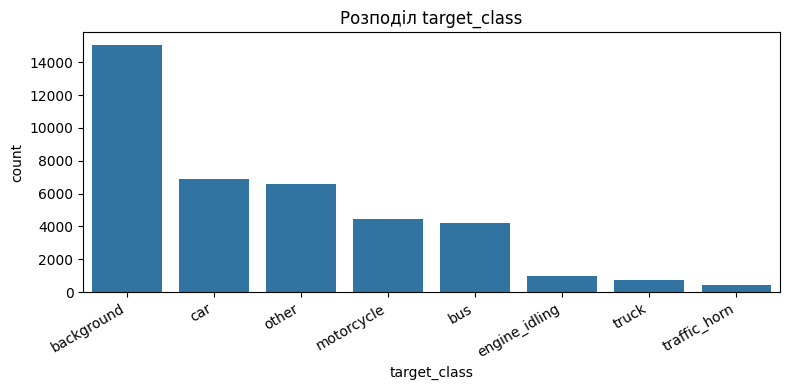

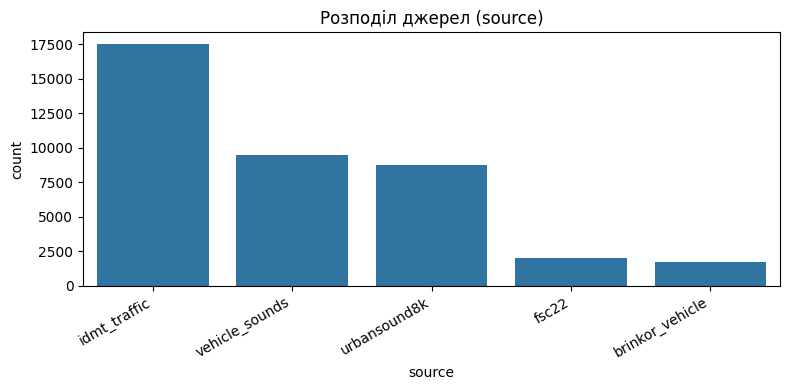

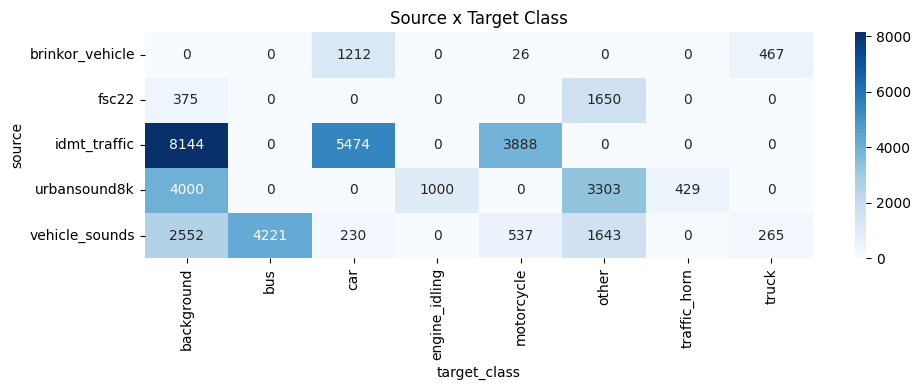

In [23]:
# Графіки по зібраному all_df
if "all_df" not in globals():
    raise RuntimeError("Спочатку запусти комірку 2e, щоб отримати all_df.")

# 1) Розподіл target_class
plt.figure(figsize=(8, 4))
order = all_df["target_class"].value_counts().index
sns.countplot(data=all_df, x="target_class", order=order)
plt.title("Розподіл target_class")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# 2) Розподіл по джерелах (source)
plt.figure(figsize=(8, 4))
order = all_df["source"].value_counts().index
sns.countplot(data=all_df, x="source", order=order)
plt.title("Розподіл джерел (source)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# 3) Перехресний розподіл source x target_class
pivot = all_df.pivot_table(
    index="source",
    columns="target_class",
    values="file_path",
    aggfunc="count",
    fill_value=0,
)
plt.figure(figsize=(10, 4))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues")
plt.title("Source x Target Class")
plt.tight_layout()
plt.show()

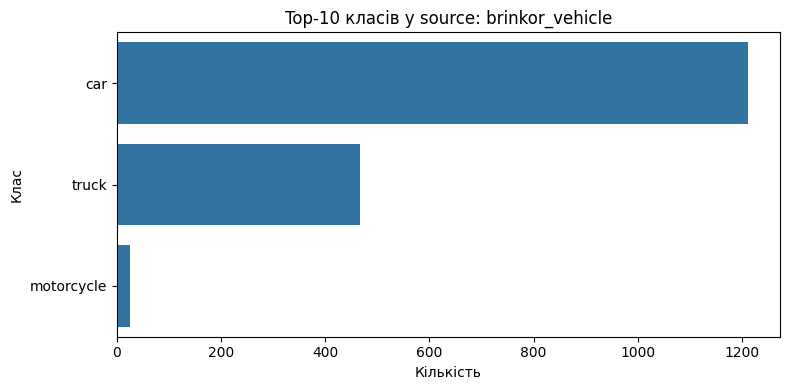

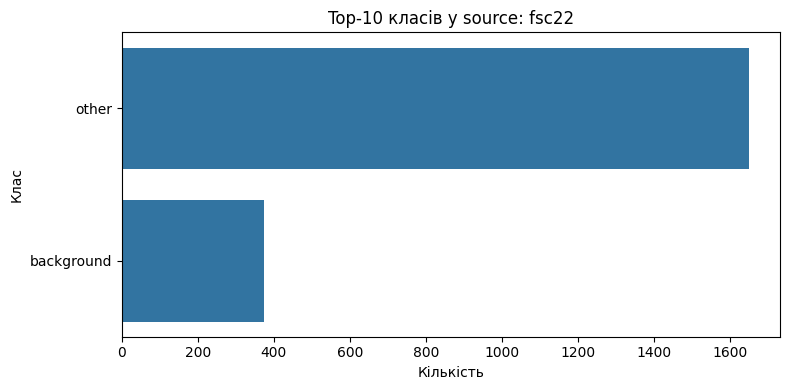

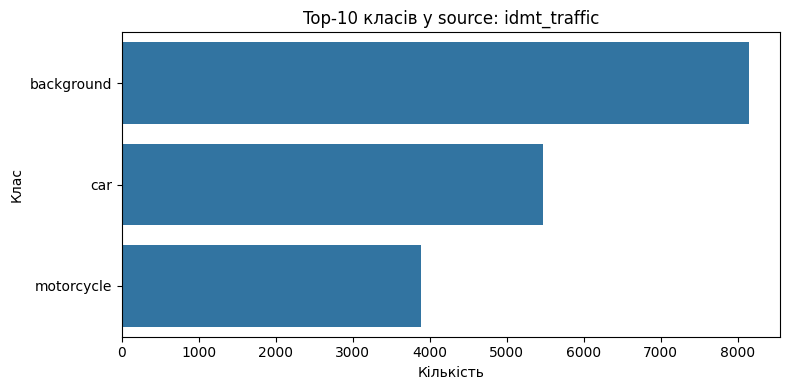

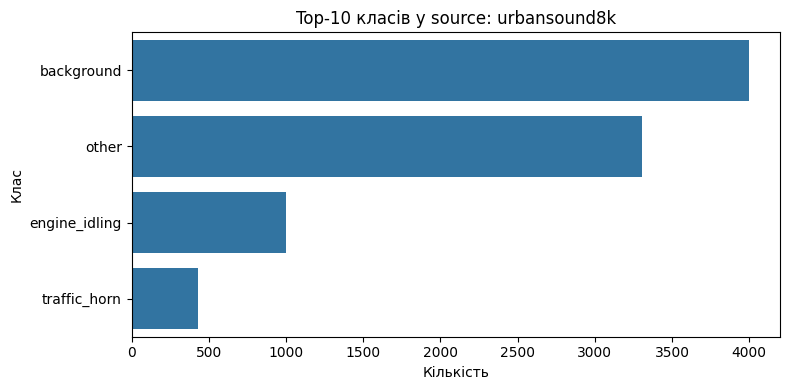

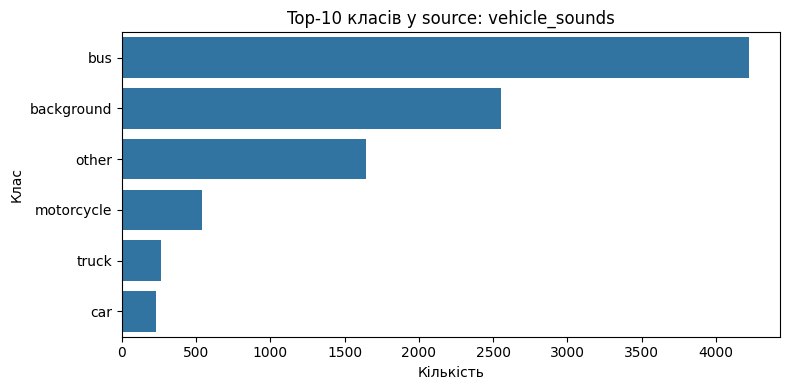

In [24]:
# 4) Top-10 класів у кожному source (bar chart)
if "all_df" not in globals():
    raise RuntimeError("Спочатку запусти комірку 2e, щоб отримати all_df.")

# Рахуємо топ-10 класів по кожному source
counts = (
    all_df.groupby(["source", "target_class"])
    .size()
    .reset_index(name="count")
)

sources = counts["source"].unique()
for src in sources:
    top = counts[counts["source"] == src].nlargest(10, "count")
    if top.empty:
        continue
    plt.figure(figsize=(8, 4))
    sns.barplot(data=top, x="count", y="target_class")
    plt.title(f"Top-10 класів у source: {src}")
    plt.xlabel("Кількість")
    plt.ylabel("Клас")
    plt.tight_layout()
    plt.show()

Аналізуємо файл: Car_Sound___Sound_effect___driving_3.wav
Клас: car | Джерело: vehicle_sounds

📊 МАТРИЦЯ ДЛЯ ВХОДУ В НЕЙРОМЕРЕЖУ: (64, 63)
💾 Об'єм вхідного тензора в RAM: 15.75 КБ



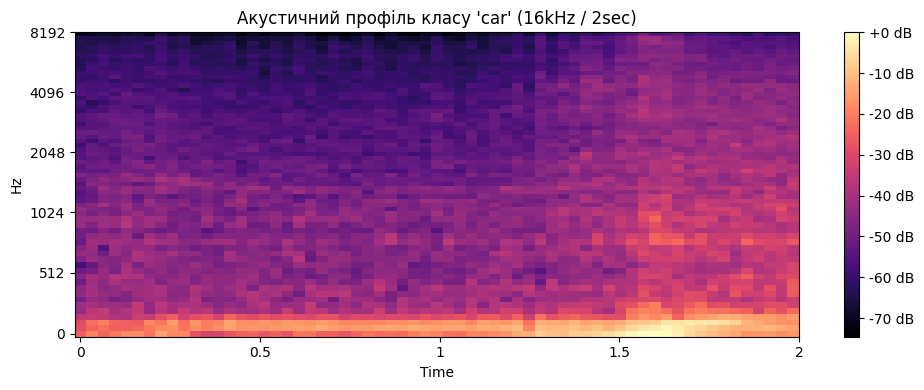

In [25]:
# Задаємо константи під залізо STM32
SR = 16000        # 16 кГц
DURATION = 2.0    # 2 секунди
N_MELS = 64       # 64 частотні смуги

# 1. Витягуємо будь-який випадковий файл, наприклад, автомобіль або мотоцикл
sample_row = all_df[all_df["target_class"].isin(["car", "motorcycle"])].iloc[5]
test_file = sample_row["file_path"]

print(f"Аналізуємо файл: {os.path.basename(test_file)}")
print(f"Клас: {sample_row['target_class']} | Джерело: {sample_row['source']}")

# 2. Завантаження файлу з автоматичним ресемплінгом до 16 кГц
y, sr = librosa.load(test_file, sr=SR)

# 3. Приведення тривалості строго до 2.0 секунд (фіксація розміру вхідного вектора)
target_samples = int(SR * DURATION)
if len(y) > target_samples:
    y = y[:target_samples]
else:
    y = np.pad(y, (0, target_samples - len(y)), mode='constant')

# 4. Розрахунок Мел-спектрограми (аналог того, що робитиме ARM CMSIS-DSP)
S = librosa.feature.melspectrogram(
    y=y, 
    sr=sr, 
    n_mels=N_MELS, 
    n_fft=1024, 
    hop_length=512
)

# Логарифмування амплітуди (перевід у децибели, близькі до людського сприйняття)
S_dB = librosa.power_to_db(S, ref=np.max)

print("\n" + "="*50)
print(f"📊 МАТРИЦЯ ДЛЯ ВХОДУ В НЕЙРОМЕРЕЖУ: {S_dB.shape}")
print(f"💾 Об'єм вхідного тензора в RAM: {S_dB.nbytes / 1024:.2f} КБ")
print("="*50 + "\n")

# 5. Графічне відображення акустичного відбитку
plt.figure(figsize=(10, 4))
librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title(f"Акустичний профіль класу '{sample_row['target_class']}' (16kHz / 2sec)")
plt.tight_layout()
plt.show()

In [26]:
def normalize_label(label):
    return str(label).strip().lower().replace(" ", "_").replace("-", "_")


def find_csv(root, hint=None):
    candidates = glob.glob(os.path.join(root, "**", "*.csv"), recursive=True)
    if hint:
        for p in candidates:
            if hint.lower() in os.path.basename(p).lower():
                return p
    return candidates[0] if candidates else None


# --- ОНОВЛЕНІ ПАРСЕРИ (З ПРАВИЛЬНИМИ МІТКАМИ) ---

def build_urban_df(root):
    if not root or not os.path.isdir(root): return None
    csv_path = find_csv(root, "UrbanSound8K")
    if not csv_path: return None
    meta = pd.read_csv(csv_path)
    file_paths = meta.apply(lambda r: os.path.join(root, f"fold{r['fold']}", r["slice_file_name"]), axis=1)
    return pd.DataFrame({"file_path": file_paths, "label": meta["class"].astype(str), "source": "urbansound8k"})


def build_fsc_df(root):
    if not root or not os.path.isdir(root): return None
    csv_path = find_csv(root, "FSC22") or find_csv(root, "meta")
    if not csv_path: return None
    meta = pd.read_csv(csv_path)
    file_col = "Dataset File Name" if "Dataset File Name" in meta.columns else "DatasetFileName"
    label_col = "Class Name" if "Class Name" in meta.columns else "ClassName"
    all_wavs = glob.glob(os.path.join(root, "**", "*.wav"), recursive=True)
    wav_map = {os.path.basename(f): f for f in all_wavs}
    file_paths = meta[file_col].apply(lambda f: wav_map.get(str(f).strip()))
    return pd.DataFrame({"file_path": file_paths, "label": meta[label_col].astype(str), "source": "fsc22"})


def build_vehicle_df(root):
    if not root or not os.path.isdir(root): return None
    wavs = glob.glob(os.path.join(root, "**", "*.wav"), recursive=True)
    labels = [os.path.basename(os.path.dirname(p)) for p in wavs]
    return pd.DataFrame({"file_path": wavs, "label": labels, "source": "vehicle_sounds"})


def build_idmt_df(root):
    """ВИПРАВЛЕНО: Парсинг за офіційним шифром (A, C, M, B, T, BG)."""
    if not root or not os.path.isdir(root): return None
    print("🔍 Розумна індексація IDMT-Traffic...")
    wavs = glob.glob(os.path.join(root, "**", "*.wav"), recursive=True)
    labels = []
    for p in wavs:
        fn = os.path.splitext(os.path.basename(p))[0]
        if "-bg" in fn.lower():
            labels.append("background")
        else:
            parts = fn.split('_')
            if len(parts) >= 5:
                code = parts[4].lower()
                mapping = {'a': 'car', 'c': 'car', 'm': 'motorcycle', 'b': 'bus', 't': 'truck'}
                labels.append(mapping.get(code, "other"))
            else:
                labels.append("other")
    return pd.DataFrame({"file_path": wavs, "label": labels, "source": "idmt_traffic"})


def build_brinkor_df(root):
    """ВИПРАВЛЕНО: Мапінг через labels.csv."""
    if not root or not os.path.isdir(root): return None
    csv_path = find_csv(root, "labels")
    if not csv_path: return None
    print("🔍 Розумна індексація Brinkor (Vehicle Noise)...")
    meta = pd.read_csv(csv_path)
    all_wavs = glob.glob(os.path.join(root, "**", "*.wav"), recursive=True)
    wav_map = {''.join(filter(str.isdigit, os.path.basename(f))): f for f in all_wavs}
    file_paths = [wav_map.get(str(i)) for i in meta.index]
    class_map = {0: "car", 1: "truck", 2: "motorcycle"}
    return pd.DataFrame({"file_path": file_paths, "label": meta["class"].map(class_map), "source": "brinkor_vehicle"})


# --- ЗБІРКА ---
u_root = globals().get("urban_root")
f_root = globals().get("fsc22_root") or globals().get("fsc_root")
v_root = globals().get("vehicle_root")
idmt_r = globals().get("idmt_root")
brinkor_r = globals().get("brinkor_root")

frames = [build_urban_df(u_root), build_fsc_df(f_root), build_vehicle_df(v_root), build_idmt_df(idmt_r), build_brinkor_df(brinkor_r)]
all_df = pd.concat([df for df in frames if df is not None], ignore_index=True)
all_df["label_norm"] = all_df["label"].apply(normalize_label)
all_df["exists"] = all_df["file_path"].apply(lambda x: os.path.isfile(x) if x else False)

# Мапінг у target_class
class_mapping = {
    "cars": "car", "car": "car", "motocycles": "motorcycle", "motorcycle": "motorcycle", 
    "bus": "bus", "truck": "truck", "background": "background", 
    "car_horn": "traffic_horn", "engine_idling": "engine_idling",
    "air_conditioner": "background", "street_music": "background", 
    "children_playing": "background", "birdchirping": "background"
}


def map_to_target(label):
    if label in class_mapping: return class_mapping[label]
    if any(kw in label for kw in ["voice", "laughter", "clapping", "dog_bark", "rain"]): return "background"
    return "other"


all_df["target_class"] = all_df["label_norm"].apply(map_to_target)

print("\n" + "="*50 + "\n🔥 ФІНАЛЬНИЙ РОЗПОДІЛ (МАЄ БУТИ ЗБАЛАНСОВАНО):\n" + "="*50)
print(all_df["target_class"].value_counts())

🔍 Розумна індексація IDMT-Traffic...
🔍 Розумна індексація Brinkor (Vehicle Noise)...

🔥 ФІНАЛЬНИЙ РОЗПОДІЛ (МАЄ БУТИ ЗБАЛАНСОВАНО):
target_class
background       14921
car               6916
other             6746
motorcycle        4451
bus               4221
engine_idling     1000
truck              732
traffic_horn       429
Name: count, dtype: int64


## 3) Load WAVs and Extract MFCC

In [27]:
# 1. Параметри (строго під STM32)
SR = 16000
DURATION = 2.0
SAMPLES_PER_CLIP = int(SR * DURATION)
N_MELS = 64
N_FFT = 1024
HOP_LENGTH = 512

# 2. Визначаємо класи, які ми реально хочемо вчити
# Ми можемо виключити 'other', якщо він надто зашумлений
TARGET_CLASSES = ['car', 'motorcycle', 'bus', 'truck', 'traffic_horn', 'engine_idling', 'background']
class_to_idx = {name: i for i, name in enumerate(TARGET_CLASSES)}


def extract_log_mel(path):
    """Завантаження та конвертація в спектрограму (64x63)."""
    try:
        # Завантаження
        audio, _ = librosa.load(path, sr=SR, mono=True, duration=DURATION)

        # Padding / Cropping до 2 секунд
        if len(audio) < SAMPLES_PER_CLIP:
            audio = np.pad(audio, (0, SAMPLES_PER_CLIP - len(audio)))
        else:
            audio = audio[:SAMPLES_PER_CLIP]

        # Спектрограма
        mel_spec = librosa.feature.melspectrogram(
            y=audio, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH
        )

        # Перевід у логарифмічну шкалу (Log-Mel)
        log_mel = librosa.power_to_db(mel_spec, ref=np.max)
        return log_mel.astype(np.float32)
    except Exception:
        return None


# 3. Основна функція збірки
def build_final_dataset(df):
    X = []
    y = []

    # Фільтруємо лише потрібні нам класи
    df_filtered = df[df['target_class'].isin(TARGET_CLASSES)].copy()

    print(f"Починаємо обробку {len(df_filtered)} файлів...")

    for _, row in tqdm(df_filtered.iterrows(), total=len(df_filtered)):
        features = extract_log_mel(row['file_path'])

        if features is not None:
            X.append(features)
            y.append(class_to_idx[row['target_class']])

    return np.array(X), np.array(y)


# ЗАПУСК
X, y = build_final_dataset(all_df)

# Додаємо вимір каналу (як для картинки: Batch, Height, Width, Channels)
# Це потрібно для Keras Conv2D шарів
X = X[..., np.newaxis]

print("\n" + "="*30)
print("✅ Готово!")
print(f"X shape: {X.shape} (Кількість, Висота, Ширина, Канал)")
print(f"y shape: {y.shape}")
print(f"Мапінг класів: {class_to_idx}")

Починаємо обробку 32670 файлів...


100%|██████████| 32670/32670 [04:30<00:00, 120.70it/s]



✅ Готово!
X shape: (32670, 64, 63, 1) (Кількість, Висота, Ширина, Канал)
y shape: (32670,)
Мапінг класів: {'car': 0, 'motorcycle': 1, 'bus': 2, 'truck': 3, 'traffic_horn': 4, 'engine_idling': 5, 'background': 6}


In [28]:
np.savez_compressed('processed_data.npz', X=X, y=y)

In [29]:
# 1. Створюємо мапінг: старі мітки -> нові (по порядку)
unique_labels = sorted(np.unique(y))
label_map = {old_val: new_val for new_val, old_val in enumerate(unique_labels)}

print(f"Старі мітки: {unique_labels}")
print(f"Новий мапінг: {label_map}")

# 2. Перекодовуємо весь масив y
y_new = np.array([label_map[val] for val in y])

# 3. Оновлюємо кількість класів
num_classes = len(unique_labels)
print(f"Нова кількість класів: {num_classes}")
print(f"Нові унікальні мітки: {np.unique(y_new)}")

# ТЕПЕР заміни старий y на y_new і запускай розбивку та навчання
y = y_new

Старі мітки: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Новий мапінг: {np.int64(0): 0, np.int64(1): 1, np.int64(2): 2, np.int64(3): 3, np.int64(4): 4, np.int64(5): 5, np.int64(6): 6}
Нова кількість класів: 7
Нові унікальні мітки: [0 1 2 3 4 5 6]


## 4) Train/Val Split and Input Shaping

In [53]:
# 1. Нормалізація
X_norm = (X - np.min(X)) / (np.max(X) - np.min(X))

# 2. Жорстке виправлення розмірності (Input Shaping)
# Нам потрібно (Кількість, 64, 63, 1)
# Якщо випадково з'явилися зайві одиниці в кінці, ми їх прибираємо
if X_norm.ndim > 4:
    X_norm = np.squeeze(X_norm) 

# Якщо каналу взагалі немає (ndim == 3), додаємо його
if X_norm.ndim == 3:
    X_norm = X_norm[..., np.newaxis]

# На всякий випадок примусово робимо фінальний reshape
X_norm = X_norm.reshape(-1, 64, 63, 1)

# 3. Розподіл на навчання та валідацію
X_train, X_val, y_train, y_val = train_test_split(
    X_norm, y, test_size=0.2, random_state=42, stratify=y
)

# 1. Рахуємо базові ваги (як і було)
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))

# 2. РУЧНЕ КОРЕГУВАННЯ ВАГ КЛАСІВ (як було до тюнінгу)
truck_index = class_to_idx.get("truck")
car_index = class_to_idx.get("car")

# Зменшуємо вагу вантажівки, щоб зменшити хибні спрацювання
if truck_index is not None:
    class_weights[truck_index] = class_weights[truck_index] * 0.6

# Трохи піднімемо вагу для car, щоб активніше "відвойовувала" свої файли
if car_index is not None:
    class_weights[car_index] = class_weights[car_index] * 1.3

print("Оновлені ваги класів:", class_weights)

print(f"Фінальна форма X_train: {X_train.shape}") # Має бути (N, 64, 63, 1)
print(f"Вхідна розмірність для моделі: {X_train.shape[1:]}") # Має бути (64, 63, 1)

Оновлені ваги класів: {0: np.float64(0.8772507810281169), 1: np.float64(1.0485016247442531), 2: np.float64(1.1056305258259655), 3: np.float64(3.8294505494505495), 4: np.float64(10.885464389837567), 5: np.float64(4.667142857142857), 6: np.float64(0.31278497827882096)}
Фінальна форма X_train: (26136, 64, 63, 1)
Вхідна розмірність для моделі: (64, 63, 1)


In [38]:
# Переконайся, що виведе 7
unique_labels = np.unique(y)
num_classes = len(unique_labels)
print(f"Мітки: {unique_labels}, Кількість: {num_classes}")

Мітки: [0 1 2 3 4 5 6], Кількість: 7


## 5) Build CNN Model

In [39]:
def build_tiny_cnn(input_shape, num_classes):
    model = tf.keras.Sequential([
        # Блок 1: Пошук базових ліній та шумів
        tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Блок 2: Складніші акустичні структури
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.2), # Захист від перенавчання

        # Блок 3: Фінальне виділення ознак
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Класифікаційна "голова"
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

    return model


# Ініціалізація
input_shape = X_train.shape[1:]
num_classes = len(np.unique(y))
model = build_tiny_cnn(input_shape, num_classes)

# Компіляція
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\D\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 63, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 31, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3584)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       229,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 253,191 (989.03 KB)

 Trainable params: 253,191 (989.03 KB)

 Non-trainable params: 0 (0.00 B)

## 6) Train and Evaluate

Epoch 1/40
817/817 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9355 - loss: 0.1301 - val_accuracy: 0.9216 - val_loss: 0.2628
Epoch 2/40
817/817 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9224 - loss: 0.1673 - val_accuracy: 0.8967 - val_loss: 0.3224
Epoch 3/40
817/817 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9195 - loss: 0.1718 - val_accuracy: 0.9241 - val_loss: 0.2534
Epoch 4/40
817/817 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9343 - loss: 0.1390 - val_accuracy: 0.9010 - val_loss: 0.3060
Epoch 5/40
817/817 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9314 - loss: 0.1370 - val_accuracy: 0.9183 - val_loss: 0.2770
Epoch 6/40
817/817 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9292 - loss: 0.1369 - val_accuracy: 0.9154 - val_loss: 0.2607
Epoch 7/40
817/817 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9309 - loss: 0.1513 - val_accuracy: 0.8298 - val_loss: 0.5017
Epoch 8/40
817/817 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9018 - loss: 0.2276 - val_accuracy: 0.

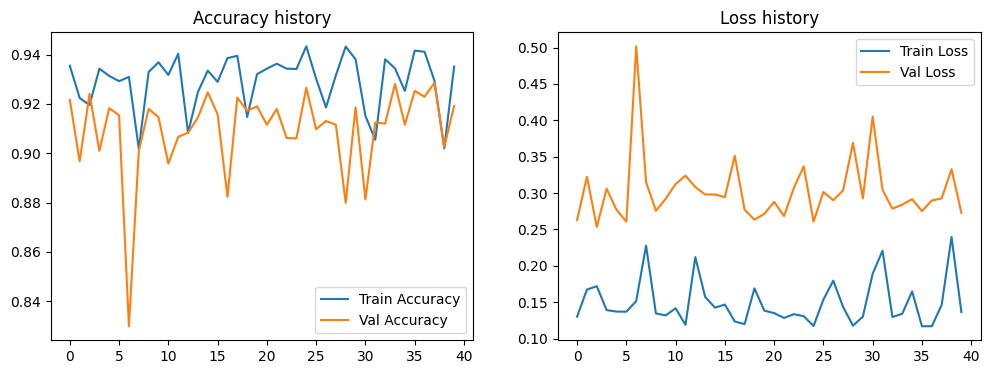

In [54]:
# 1. Запуск навчання
EPOCHS = 40
BATCH_SIZE = 32

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    verbose=1
)

# 2. Оцінка результатів
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"\nФінальна точність на валідації: {val_acc*100:.2f}%")

# 3. Візуалізація графіків
plt.figure(figsize=(12, 4))

# Графік точності
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy history')
plt.legend()

# Графік втрат
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss history')
plt.legend()

plt.show()

205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

📝 КЛАСИФІКАЦІЙНИЙ ЗВІТ (Classification Report):
               precision    recall  f1-score   support

          car       0.94      0.84      0.89      1383
   motorcycle       0.94      0.74      0.83       890
          bus       0.99      0.99      0.99       844
        truck       0.63      0.74      0.68       147
 traffic_horn       0.82      0.97      0.89        86
engine_idling       0.87      0.93      0.90       200
   background       0.89      0.97      0.93      2984

     accuracy                           0.91      6534
    macro avg       0.87      0.88      0.87      6534
 weighted avg       0.91      0.91      0.91      6534



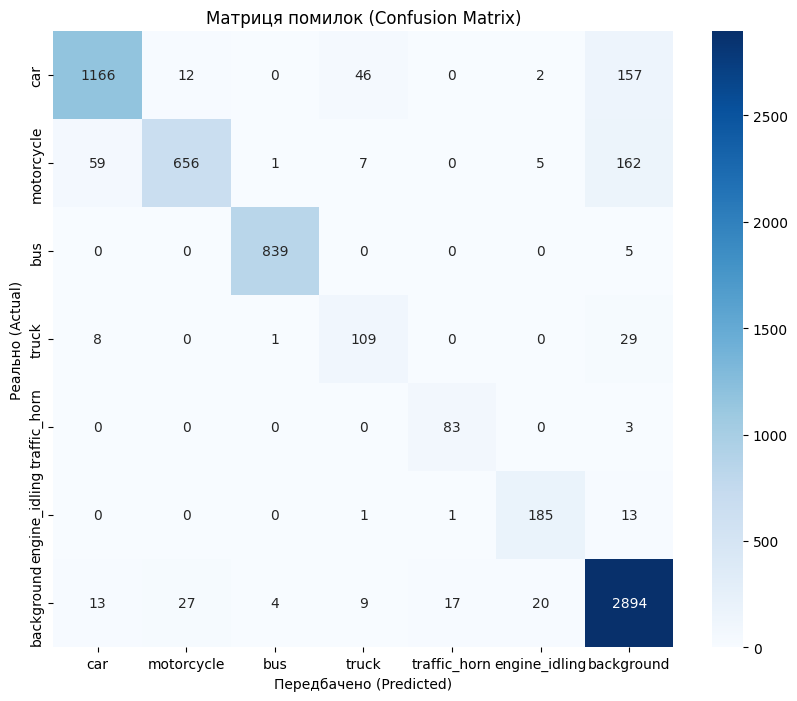

In [55]:
# 1. Отримуємо ймовірності (а не просто номери класів)
y_pred_probs = model.predict(X_val)

# 2. Логіка з порогом: якщо модель впевнена менше ніж на 70% — це background
threshold = 0.7
y_pred_final = []
bg_index = class_to_idx.get("background", len(np.unique(y)) - 1)

for probs in y_pred_probs:
    if np.max(probs) < threshold:
        y_pred_final.append(bg_index)
    else:
        y_pred_final.append(np.argmax(probs))

y_pred = np.array(y_pred_final)

# 3. Дивимось на результат
target_names = [name for name, _ in sorted(class_to_idx.items(), key=lambda kv: kv[1])]
# 3. Вивід текстового звіту (Precision, Recall, F1)
print("\n" + "="*60)
print("📝 КЛАСИФІКАЦІЙНИЙ ЗВІТ (Classification Report):")
print("="*60)
print(classification_report(y_val, y_pred, target_names=target_names))

# 4. Візуалізація матриці помилок (Confusion Matrix)
# Це покаже, які класи модель плутає найчастіше
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Передбачено (Predicted)')
plt.ylabel('Реально (Actual)')
plt.title('Матриця помилок (Confusion Matrix)')
plt.show()

## 7) Export INT8 TFLite

In [ ]:
# 1. Зберігаємо оригінальну модель
model.save('traffic_model.h5')

# 2. Функція-генератор репрезентативного датасету
# Це потрібно для калібрування квантування (щоб нейромережа знала діапазон чисел)
def representative_data_gen():
    for input_value in tf.data.Dataset.from_tensor_slices(X_val.astype(np.float32)).batch(1).take(100):
        yield [input_value]

# 3. Конвертація в TFLite з квантуванням INT8
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model_quant = converter.convert()

# 4. Збереження готового файлу
with open('traffic_model_int8.tflite', 'wb') as f:
    f.write(tflite_model_quant)

print("✅ Модель успішно квантована в INT8!")

INFO:tensorflow:Assets written to: C:\Users\D\AppData\Local\Temp\tmpgpe5l9hc\assets


INFO:tensorflow:Assets written to: C:\Users\D\AppData\Local\Temp\tmpgpe5l9hc\assets


Saved artifact at 'C:\Users\D\AppData\Local\Temp\tmpgpe5l9hc'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 63, 1), dtype=tf.float32, name='keras_tensor_13')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  1931989660496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1931989658192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1931989658768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1931989657040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1931989657808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1931989656080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1931989656272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1931989655696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1931989655888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1931989655312: TensorSpec(shape=(), dtype=tf.resource, name=None)


C:\Users\D\AppData\Roaming\Python\Python313\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


✅ Модель успішно квантована в INT8!


## 8) Convert TFLite to C Array
Generate a C header for X-CUBE-AI integration.

In [ ]:
size_h5 = os.path.getsize('traffic_model.h5') / 1024
size_tflite = os.path.getsize('traffic_model_int8.tflite') / 1024

print(f"Вага оригінальної моделі (.h5): {size_h5:.2f} KB")
print(f"Вага квантованої моделі (.tflite): {size_tflite:.2f} KB")

Вага оригінальної моделі (.h5): 3018.14 KB
Вага квантованої моделі (.tflite): 257.75 KB
